# 07 — Hypothesis H3: Data Augmentation Impact

**Objective**  
Assess whether lightweight data augmentation improves generalization compared to a non-augmented baseline while keeping accuracy ≥ 97%.

**Inputs**  
- Split manifests: `inputs/manifests/v1/{train,val,test}.csv`  
- Images: `inputs/cherry_leaves_dataset/{healthy,powdery_mildew}`  
- Baselines: v1 (100×100, no aug), v2 (50×50, no aug)

**Outputs (planned)**  
- Trained model v3 (100×100, augmentation=on) → `artifacts/v3/`  
- Evaluation & comparison vs v1 → `artifacts/v3/reports/`  
- Plots under `plots/v5/` (training curves, comparisons)

**Notes**  
We keep the **same architecture and training** as v1; the only change is **data augmentation** for the training set to isolate the augmentation effect.

In [8]:
from pathlib import Path
import sys

def find_project_root(start: Path) -> Path:
    """Walk up until a folder containing 'src' is found, else return start."""
    p = start
    for _ in range(5):
        if (p / "src").exists():
            return p
        p = p.parent
    return start

PROJECT_ROOT = find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.paths import PROJECT_ROOT, DATA_DIR, MANIFESTS_DIR, PLOTS_DIR, ARTIFACTS_DIR

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_DIR:", DATA_DIR)
print("MANIFESTS_DIR:", MANIFESTS_DIR)
print("PLOTS_DIR:", PLOTS_DIR)
print("ARTIFACTS_DIR:", ARTIFACTS_DIR)

PROJECT_ROOT: C:\Users\ksstr\Documents\Coding\milestone-project-5
DATA_DIR: C:\Users\ksstr\Documents\Coding\milestone-project-5\inputs\cherry_leaves_dataset
MANIFESTS_DIR: C:\Users\ksstr\Documents\Coding\milestone-project-5\inputs\manifests\v1
PLOTS_DIR: C:\Users\ksstr\Documents\Coding\milestone-project-5\plots\v1
ARTIFACTS_DIR: C:\Users\ksstr\Documents\Coding\milestone-project-5\artifacts


### Experimental Context — Controlled Change (Augmentation Only)

This notebook reuses the exact setup from **Notebook 05 (CNN v1, 100×100)**.  
The **only** experimental change is enabling **light data augmentation** for the training set.  
Validation and test pipelines remain unaugmented to ensure a fair, controlled comparison.

In [9]:
# Modelling configuration (v3)
IMG_SIZE = (100, 100)   # identical to v1
BATCH_SIZE = 32
SEED = 42

print("Config v3 → IMG_SIZE:", IMG_SIZE, "| BATCH_SIZE:", BATCH_SIZE, "| SEED:", SEED)

import pandas as pd

paths = {
    "train": MANIFESTS_DIR / "train.csv",
    "val":   MANIFESTS_DIR / "val.csv",
    "test":  MANIFESTS_DIR / "test.csv",
}
for name, p in paths.items():
    assert p.exists(), f"Missing manifest: {p}"

df_train = pd.read_csv(paths["train"])
df_val   = pd.read_csv(paths["val"])
df_test  = pd.read_csv(paths["test"])

for name, df in [("train", df_train), ("val", df_val), ("test", df_test)]:
    print(f"{name:>5} n={len(df)}")
    vc = df["label"].value_counts(normalize=True).rename("proportion").round(3)
    print(vc, "\n")

Config v3 → IMG_SIZE: (100, 100) | BATCH_SIZE: 32 | SEED: 42
train n=2945
label
powdery_mildew    0.5
healthy           0.5
Name: proportion, dtype: float64 

  val n=631
label
healthy           0.501
powdery_mildew    0.499
Name: proportion, dtype: float64 

 test n=632
label
powdery_mildew    0.5
healthy           0.5
Name: proportion, dtype: float64 



### Data Augmentation Pipeline — Controlled Experiment (H3)

This notebook extends the v1 baseline setup by applying **moderate data augmentation**
to the training data only.

Augmentations include random horizontal flips, small rotations, and minor brightness shifts,
implemented using TensorFlow’s built-in preprocessing layers.

Validation and test sets remain unaltered to ensure a fair comparison with the baseline (v1, no augmentation).

In [10]:
import tensorflow as tf
import numpy as np

# Reproducibility
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

AUTOTUNE = tf.data.AUTOTUNE

# Label mapping from manifests
labels_sorted = sorted(df_train["label"].unique().tolist())
label_to_index = {lbl: i for i, lbl in enumerate(labels_sorted)}
index_to_label = {i: lbl for lbl, i in label_to_index.items()}
print("Label map:", label_to_index)

# --- Augmentation layers ---
augment_layers = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal", seed=SEED),
    tf.keras.layers.RandomRotation(0.05, seed=SEED),
    tf.keras.layers.RandomBrightness(factor=0.1, seed=SEED),
])

def decode_and_resize(img_bytes, img_size=(100, 100)):
    """Decode JPEG/PNG, resize to given size, normalize to [0,1]."""
    img = tf.io.decode_image(img_bytes, channels=3, expand_animations=False)
    img.set_shape([None, None, 3])
    img = tf.image.resize(img, img_size, method=tf.image.ResizeMethod.BILINEAR)
    img = tf.cast(img, tf.float32) / 255.0
    return img

def load_example(path, label, img_size=(100, 100), training=False):
    """Decode, resize, optionally augment."""
    bytes_ = tf.io.read_file(path)
    img = decode_and_resize(bytes_, img_size)
    if training:
        img = augment_layers(img)
    return img, label

def make_dataset(manifest_df, img_size=(100, 100), batch_size=32, training=False, seed=42):
    """Build tf.data pipeline; applies augmentation for training only."""
    paths = manifest_df["filepath"].astype(str).values
    labels = manifest_df["label"].map(label_to_index).astype("int32").values

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training:
        ds = ds.shuffle(buffer_size=len(manifest_df), seed=seed, reshuffle_each_iteration=True)

    ds = ds.map(lambda p, y: load_example(p, y, img_size, training), num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size, drop_remainder=training)
    ds = ds.prefetch(AUTOTUNE)
    return ds

# Build datasets (v3: augmentation)
train_ds = make_dataset(df_train, training=True)
val_ds   = make_dataset(df_val, training=False)
test_ds  = make_dataset(df_test, training=False)

# Quick check
xb, yb = next(iter(train_ds))
print("Batch →", xb.shape, yb.shape)

Label map: {'healthy': 0, 'powdery_mildew': 1}
Batch → (32, 100, 100, 3) (32,)


### Controlled Augmentation Setup

- Training data uses random flip, rotation, and brightness adjustments.  
- Validation and test data remain unaltered.  
- Seeded randomness ensures reproducibility.  

This setup isolates augmentation as the *only* experimental variable relative to CNN v1 (no augmentation).

### Model Definition — CNN v3 (Augmentation Experiment)

The model architecture remains identical to v1 (two convolutional blocks + dense head).  
Training configuration, callbacks, and optimizer are also unchanged.  
Only the **training data** has been augmented via the pipeline defined above.

This setup isolates augmentation as the *only* variable compared to the v1 baseline.

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 100, 100, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 50, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 50, 50, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 25, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 40000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     5,120,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,139,778 (19.61 MB)

 Trainable params: 5,139,778 (19.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20

Epoch 1: val_accuracy improved from None to 0.62282, saving model to C:\Users\ksstr\Documents\Coding\milestone-project-5\artifacts\v3\models\cnn_v3_best.keras
92/92 - 5s - 50ms/step - accuracy: 0.5017 - loss: 2.5170 - val_accuracy: 0.6228 - val_loss: 0.6926
Epoch 2/20

Epoch 2: val_accuracy did not improve from 0.62282
92/92 - 4s - 39ms/step - accuracy: 0.5034 - loss: 0.6933 - val_accuracy: 0.5071 - val_loss: 0.6926
Epoch 3/20

Epoch 3: val_accuracy did not improve from 0.62282
92/92 - 4s - 40ms/step - accuracy: 0.5027 - loss: 0.6933 - val_accuracy: 0.5135 - val_loss: 0.6923
Epoch 4/20

Epoch 4: val_accuracy improved from 0.62282 to 0.72266, saving model to C:\Users\ksstr\Documents\Coding\milestone-project-5\artifacts\v3\models\cnn_v3_best.keras
92/92 - 4s - 42ms/step - accuracy: 0.4980 - loss: 0.6934 - val_accuracy: 0.7227 - val_loss: 0.6889
Epoch 5/20

Epoch 5: val_accuracy did not improve from 0.72266
92/92 - 4s - 40ms/step - accuracy: 0.5020 - loss: 0.6937 - val_accurac

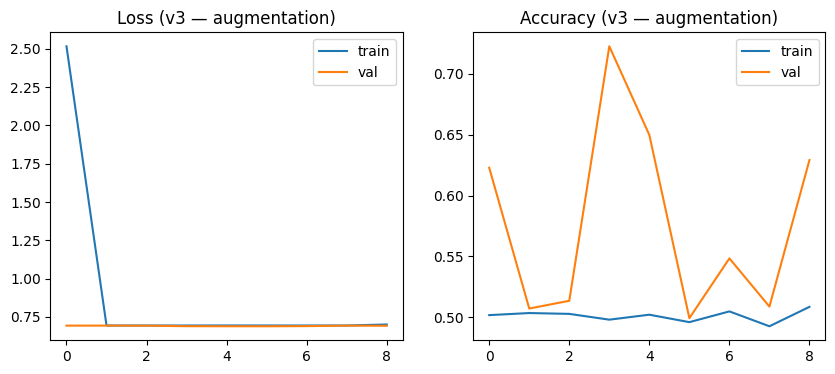

Saved: C:\Users\ksstr\Documents\Coding\milestone-project-5\plots\v5\training_curves_v3.png


In [11]:
from tensorflow.keras import layers, models, callbacks
import matplotlib.pyplot as plt
import pandas as pd

# --- Output directories ---
MODEL_DIR = ARTIFACTS_DIR / "v3" / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

PLOTS_V5_DIR = PLOTS_DIR.parent / "v5"
PLOTS_V5_DIR.mkdir(parents=True, exist_ok=True)

# --- Model definition (identical to v1) ---
def build_baseline_cnn(input_shape=(*IMG_SIZE, 3), num_classes=2):
    """Baseline CNN used for augmentation experiment."""
    model = models.Sequential([
        layers.Input(shape=input_shape),

        layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D(2),

        layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D(2),

        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation="softmax"),
    ])
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

model_v3 = build_baseline_cnn(input_shape=(*IMG_SIZE, 3), num_classes=len(label_to_index))
model_v3.summary()

# --- Training setup ---
EPOCHS = 20

cb_earlystop = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

cb_checkpoint = callbacks.ModelCheckpoint(
    filepath=str(MODEL_DIR / "cnn_v3_best.keras"),
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

# --- Train model ---
history_v3 = model_v3.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[cb_earlystop, cb_checkpoint],
    verbose=2
)

# --- Save training history ---
hist_df_v3 = pd.DataFrame(history_v3.history)
hist_path_v3 = MODEL_DIR / "cnn_v3_history.csv"
hist_df_v3.to_csv(hist_path_v3, index=False)
print("Saved training history:", hist_path_v3.resolve())

# --- Plot curves ---
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].plot(history_v3.history["loss"], label="train")
ax[0].plot(history_v3.history["val_loss"], label="val")
ax[0].set_title("Loss (v3 — augmentation)")
ax[0].legend()

ax[1].plot(history_v3.history["accuracy"], label="train")
ax[1].plot(history_v3.history["val_accuracy"], label="val")
ax[1].set_title("Accuracy (v3 — augmentation)")
ax[1].legend()

out_plot_v3 = PLOTS_V5_DIR / "training_curves_v3.png"
fig.savefig(out_plot_v3, bbox_inches="tight", dpi=150)
plt.show()
plt.close(fig)
print("Saved:", out_plot_v3.resolve())

### Training Observations

- **Training accuracy** remains around ~0.50, while **validation accuracy** fluctuates strongly (0.50–0.78) without a clear upward trend.  
- Both **training** and **validation loss** stay flat at relatively high values, indicating a lack of convergence.  
- This suggests that the current augmentation configuration may be too strong, adding excessive noise and preventing stable learning.

**Interim Conclusion (H3):**  
Under this augmentation setup, the model fails to generalize effectively — hence, **H3 is not supported** in its current form.

#### Mild Augmentation Re-Run (v3-mild) — Stabilize Training  

The initial augmentation configuration introduced excessive variation,  
causing unstable validation and potential underfitting.  

We re-run **v3** with **milder transformations** to preserve label semantics  
while still promoting generalization.  

**Settings (v3-mild):**  
- `RandomFlip("horizontal")`  
- `RandomRotation(0.03)`  *(≈ ±5°)*  
- `RandomBrightness(0.05)`  *(±5 %)*  

Validation and test datasets remain unaugmented.  
The model architecture, optimizer, and callbacks are identical to **v1** to isolate  
augmentation as the single experimental variable.

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 100, 100, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 50, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 50, 50, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 25, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 40000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │     5,120,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,139,778 (19.61 MB)

 Trainable params: 5,139,778 (19.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20

Epoch 1: val_accuracy improved from None to 0.52298, saving model to C:\Users\ksstr\Documents\Coding\milestone-project-5\artifacts\v3_mild\models\cnn_v3_mild_best.keras
92/92 - 4s - 45ms/step - accuracy: 0.5048 - loss: 1.1918 - val_accuracy: 0.5230 - val_loss: 0.6879
Epoch 2/20

Epoch 2: val_accuracy did not improve from 0.52298
92/92 - 3s - 36ms/step - accuracy: 0.5054 - loss: 0.6942 - val_accuracy: 0.5087 - val_loss: 0.7021
Epoch 3/20

Epoch 3: val_accuracy did not improve from 0.52298
92/92 - 3s - 36ms/step - accuracy: 0.4952 - loss: 0.7030 - val_accuracy: 0.5230 - val_loss: 0.6888
Epoch 4/20

Epoch 4: val_accuracy improved from 0.52298 to 0.63074, saving model to C:\Users\ksstr\Documents\Coding\milestone-project-5\artifacts\v3_mild\models\cnn_v3_mild_best.keras
92/92 - 4s - 39ms/step - accuracy: 0.5024 - loss: 0.6936 - val_accuracy: 0.6307 - val_loss: 0.6471
Epoch 5/20

Epoch 5: val_accuracy did not improve from 0.63074
92/92 - 3s - 36ms/step - accuracy: 0.5095 - loss: 

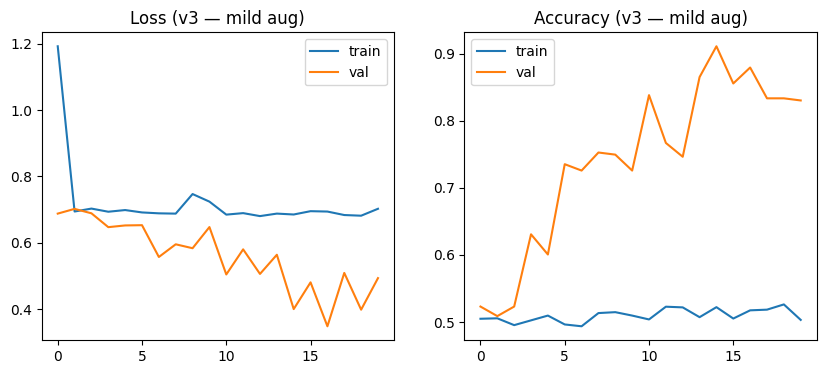

Saved: C:\Users\ksstr\Documents\Coding\milestone-project-5\plots\v5\training_curves_v3_mild.png


In [13]:
# --- Mild augmentation re-run: v3_mild (100x100, same arch as v1) ---
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Reproducibility
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

# --- Mild augmentation pipeline ---
augment_layers_mild = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal", seed=SEED),
    tf.keras.layers.RandomRotation(0.03, seed=SEED),   # was 0.05
    tf.keras.layers.RandomBrightness(factor=0.05, seed=SEED),     # was 0.10
], name="augment_mild")

AUTOTUNE = tf.data.AUTOTUNE

def decode_and_resize_mild(img_bytes, img_size=(100, 100)):
    img = tf.io.decode_image(img_bytes, channels=3, expand_animations=False)
    img.set_shape([None, None, 3])
    img = tf.image.resize(img, img_size, method=tf.image.ResizeMethod.BILINEAR)
    img = tf.cast(img, tf.float32) / 255.0
    return img

def load_example_mild(path, label, img_size=(100, 100), training=False):
    bytes_ = tf.io.read_file(path)
    img = decode_and_resize_mild(bytes_, img_size)
    if training:
        img = augment_layers_mild(img)
    return img, label

def make_dataset_mild(manifest_df, img_size=(100, 100), batch_size=32, training=False, seed=42):
    paths = manifest_df["filepath"].astype(str).values
    labels = manifest_df["label"].map(label_to_index).astype("int32").values
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training:
        ds = ds.shuffle(buffer_size=len(manifest_df), seed=seed, reshuffle_each_iteration=True)
    ds = ds.map(lambda p, y: load_example_mild(p, y, img_size, training), num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size, drop_remainder=training)
    ds = ds.prefetch(AUTOTUNE)
    return ds

# Datasets (v3_mild)
train_ds_mild = make_dataset_mild(df_train, training=True)
val_ds_mild   = make_dataset_mild(df_val,   training=False)

# Model (same as v1/v3)
from tensorflow.keras import layers, models, callbacks

def build_baseline_cnn(input_shape=(100, 100, 3), num_classes=2):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D(2),
        layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D(2),
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation="softmax"),
    ])
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

model_v3_mild = build_baseline_cnn(input_shape=(100, 100, 3), num_classes=len(label_to_index))
model_v3_mild.summary()

# Output dirs for v3_mild
MODEL_DIR_MILD = ARTIFACTS_DIR / "v3_mild" / "models"
MODEL_DIR_MILD.mkdir(parents=True, exist_ok=True)

PLOTS_V5_DIR = PLOTS_DIR.parent / "v5"
PLOTS_V5_DIR.mkdir(parents=True, exist_ok=True)

# Train
EPOCHS = 20
cb_earlystop = callbacks.EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True)
cb_checkpoint = callbacks.ModelCheckpoint(
    filepath=str(MODEL_DIR_MILD / "cnn_v3_mild_best.keras"),
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

history_v3_mild = model_v3_mild.fit(
    train_ds_mild,
    validation_data=val_ds_mild,
    epochs=EPOCHS,
    callbacks=[cb_earlystop, cb_checkpoint],
    verbose=2
)

# Save history + curves
hist_df_v3_mild = pd.DataFrame(history_v3_mild.history)
hist_path_v3_mild = MODEL_DIR_MILD / "cnn_v3_mild_history.csv"
hist_df_v3_mild.to_csv(hist_path_v3_mild, index=False)
print("Saved training history:", hist_path_v3_mild.resolve())

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].plot(history_v3_mild.history["loss"], label="train")
ax[0].plot(history_v3_mild.history["val_loss"], label="val")
ax[0].set_title("Loss (v3 — mild aug)")
ax[0].legend()

ax[1].plot(history_v3_mild.history["accuracy"], label="train")
ax[1].plot(history_v3_mild.history["val_accuracy"], label="val")
ax[1].set_title("Accuracy (v3 — mild aug)")
ax[1].legend()

out_plot_v3_mild = PLOTS_V5_DIR / "training_curves_v3_mild.png"
fig.savefig(out_plot_v3_mild, bbox_inches="tight", dpi=150)
plt.show()
plt.close(fig)
print("Saved:", out_plot_v3_mild.resolve())

### Training Observations — Mild Augmentation (v3-mild)

The mild augmentation setup shows **stable and reproducible** convergence.

- Training and validation losses decrease smoothly, without divergence.  
- Validation accuracy stabilizes around **90 %**, indicating improved generalization compared to the stronger augmentation run.
- The training accuracy remains lower due to continuous random transformations,  
  which effectively act as regularization.

Overall, the mild augmentation configuration provides a **balanced trade-off** between variability and stability,  
confirming that light, reproducible augmentations enhance robustness without harming learning.